# In vivo temperature measurements analysis

In [151]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [152]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from usnm2p.logger import logger
from usnm2p.constants import *
from usnm2p.thermal_utils import *
from usnm2p.fileops import *
from usnm2p.utils import get_singleton

### Inputs

In [ ]:
dataroot = '/Users/tlemaire/Documents/data/US_thermal_experiments'
# experiment = '20260910_M01'  
experiment = '20260911_M02'
datadir = os.path.join(dataroot, experiment)

# Root directory for output figures
figsdir = os.path.join(dataroot, 'figs')
if not os.path.exists(figsdir):
    os.makedirs(figsdir)
logger.info(f'output figures directory: "{figsdir}"')

# Figures dictionary
figs = {}

 2026/09/16 15:12:07: output figures directory: "/Users/tlemaire/Documents/data/US_thermal_experiments/figs"


### Load data

 2026/09/16 15:12:07: loading info from "/Users/tlemaire/Documents/data/US_thermal_experiments/20260910_M01/V1_center_300um" recording
 2026/09/16 15:12:07: getting sample rate from info.rhd header
 2026/09/16 15:12:07: Intan RHD version: 1.5
 2026/09/16 15:12:07: Intan RHD sample rate: 20000.0 Hz
 2026/09/16 15:12:07: Intan RHD board mode: 0
 2026/09/16 15:12:07: getting sample count and analog channel count from file sizes
 2026/09/16 15:12:07: sample count: 72801360, analog channel count: 1
 2026/09/16 15:12:07: loading analogin.dat as memmap
 2026/09/16 15:12:07: downsampling channel 0 from 20000.0 Hz to 119.760 Hz
 2026/09/16 15:12:08: converting downsampled ADC vector to volts
 2026/09/16 15:12:08: generating downsampled time vector
 2026/09/16 15:12:08: converting Osensa probe voltage to °C
 2026/09/16 15:12:08: Lowpass filtering temperature trace at 30 Hz
 2026/09/16 15:12:08: plotting longitudinal temperature recording at 3.992 Hz
 2026/09/16 15:12:09: loading digitalin.dat as

T (°C)                  timestamp  \
location               trial time (s)                                           
V1_center_300um        0     -0.491675   30.781232 2026-09-10 14:35:00.284153   
                             -0.483325   30.783989 2026-09-10 14:35:00.284153   
                             -0.474975   30.784874 2026-09-10 14:35:00.284153   
                             -0.466625   30.783472 2026-09-10 14:35:00.284153   
                             -0.458275   30.779960 2026-09-10 14:35:00.284153   
...                                            ...                        ...   
V1_lateral1000um_300um 299    29.493125  30.371425 2026-09-10 17:18:29.728376   
                              29.501475  30.376545 2026-09-10 17:18:29.728376   
                              29.509825  30.382079 2026-09-10 17:18:29.728376   
                              29.518175  30.380451 2026-09-10 17:18:29.728376   
                              29.526525  30.375686 2026-09-10 17:18:29.728376   

                                         Fdrive (MHz)  P (MPa)   Vpp (V)  \
location               trial time (s)                                      
V1_center_300um        0     -0.491675          2.095     0.57  0.127648   
                             -0.483325          2.095     0.57  0.127648   
                             -0.474975          2.095     0.57  0.127648   
                             -0.466625          2.095     0.57  0.127648   
                             -0.458275          2.095     0.57  0.127648   
...                                               ...      ...       ...   
V1_lateral1000um_300um 299    29.493125         2.095     0.57  0.127648   
                              29.501475         2.095     0.57  0.127648   
                              29.509825         2.095     0.57  0.127648   
                              29.518175         2.095     0.57  0.127648   
                              29.526525         2.095     0.57  0.127648   

                                         tstim (s)  PRF (Hz)  DC (%)  \
location               trial time (s)                                  
V1_center_300um        0     -0.491675         0.2     100.0    80.0   
                             -0.483325         0.2     100.0    80.0   
                             -0.474975         0.2     100.0    80.0   
                             -0.466625         0.2     100.0    80.0   
                             -0.458275         0.2     100.0    80.0   
...                                            ...       ...     ...   
V1_lateral1000um_300um 299    29.493125        0.2     100.0    80.0   
                              29.501475        0.2     100.0    80.0   
                              29.509825        0.2     100.0    80.0   
                              29.518175        0.2     100.0    80.0   
                              29.526525        0.2     100.0    80.0   

                                         elapsed time (s)  I_SPPA (W/cm2)  \
location               trial time (s)                                       
V1_center_300um        0     -0.491675           0.000000           10.04   
                             -0.483325           0.000000           10.04   
                             -0.474975           0.000000           10.04   
                             -0.466625           0.000000           10.04   
                             -0.458275           0.000000           10.04   
...                                                   ...             ...   
V1_lateral1000um_300um 299    29.493125       1772.924283           10.04   
                              29.501475       1772.924283           10.04   
                              29.509825       1772.924283           10.04   
                              29.518175       1772.924283           10.04   
                              29.526525       1772.924283           10.04   

                                         I_SPTA (W/cm2)  
loca

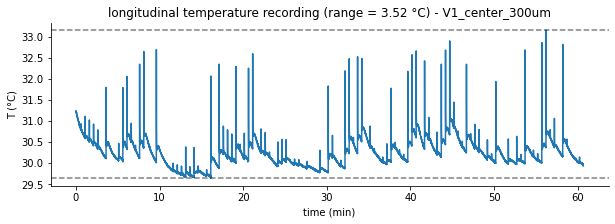

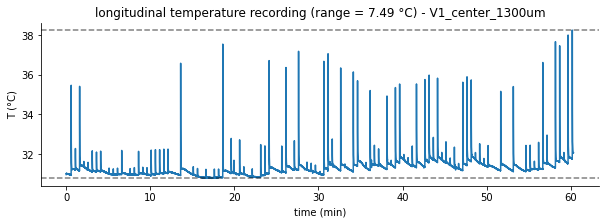

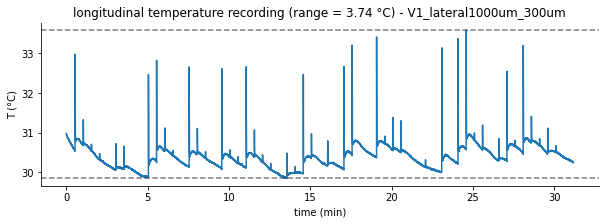

In [154]:
# Load and process the thermal experiment data
data = load_and_process_thermal_experiment(datadir, plot=True, figdict=figs)

# Rename "condition" index dimension (from different recording files) to "location"
data = data.rename_axis(index={'condition': 'location'})

# Compute ISPPA and ISPTA columns
data[Label.ISPPA] = pressure_to_intensity(data[Label.P] / PA_TO_MPA) / M2_TO_CM2  # W/cm2
data[Label.ISPTA] = data[Label.ISPPA] * data[Label.DC] / 1e2
for k in [Label.ISPPA, Label.ISPTA]:
    data[k] = data[k].round(2)

# Extract experimental duty cycle
DC = get_singleton(data, Label.DC)

logger.info('processed experiment data:')
data

### Apply trial-by-trial linear detrending and compute evoked temperature change 

In [155]:
# Restrict trial data to up to 5s post-stimulation
logger.info('restricting trial data to up to 5s post-stimulation')
data = data[data.index.get_level_values(TIME_KEY) < 5.].copy()

# Apply trial-by-trial linear detrending to the temperature data
logger.info('detrending temperature traces trial-by-trial')
data[f'detrended {TEMP_KEY}'] = (
    data
    .groupby('trial')
    [TEMP_KEY]
    .transform(detrend_trial)
)

# Compute trial-by-trial relative temperature change
logger.info('computing trial-by-trial relative temperature change')
data[REL_TEMP_KEY] = (
    data
    .groupby('trial')
    [f'detrended {TEMP_KEY}']
    .transform(compute_deltaT)
)

data

 2026/09/16 15:12:13: restricting trial data to up to 5s post-stimulation
 2026/09/16 15:12:13: detrending temperature traces trial-by-trial
 2026/09/16 15:12:13: computing trial-by-trial relative temperature change


T (°C)                  timestamp  \
location               trial time (s)                                          
V1_center_300um        0     -0.491675  30.781232 2026-09-10 14:35:00.284153   
                             -0.483325  30.783989 2026-09-10 14:35:00.284153   
                             -0.474975  30.784874 2026-09-10 14:35:00.284153   
                             -0.466625  30.783472 2026-09-10 14:35:00.284153   
                             -0.458275  30.779960 2026-09-10 14:35:00.284153   
...                                           ...                        ...   
V1_lateral1000um_300um 299    4.960825  30.505050 2026-09-10 17:18:29.728376   
                              4.969175  30.507074 2026-09-10 17:18:29.728376   
                              4.977525  30.508984 2026-09-10 17:18:29.728376   
                              4.985875  30.509084 2026-09-10 17:18:29.728376   
                              4.994225  30.504394 2026-09-10 17:18:29.728376   

                                        Fdrive (MHz)  P (MPa)   Vpp (V)  \
location               trial time (s)                                     
V1_center_300um        0     -0.491675         2.095     0.57  0.127648   
                             -0.483325         2.095     0.57  0.127648   
                             -0.474975         2.095     0.57  0.127648   
                             -0.466625         2.095     0.57  0.127648   
                             -0.458275         2.095     0.57  0.127648   
...                                              ...      ...       ...   
V1_lateral1000um_300um 299    4.960825         2.095     0.57  0.127648   
                              4.969175         2.095     0.57  0.127648   
                              4.977525         2.095     0.57  0.127648   
                              4.985875         2.095     0.57  0.127648   
                              4.994225         2.095     0.57  0.127648   

                                        tstim (s)  PRF (Hz)  DC (%)  \
location               trial time (s)                                 
V1_center_300um        0     -0.491675        0.2     100.0    80.0   
                             -0.483325        0.2     100.0    80.0   
                             -0.474975        0.2     100.0    80.0   
                             -0.466625        0.2     100.0    80.0   
                             -0.458275        0.2     100.0    80.0   
...                                           ...       ...     ...   
V1_lateral1000um_300um 299    4.960825        0.2     100.0    80.0   
                              4.969175        0.2     100.0    80.0   
                              4.977525        0.2     100.0    80.0   
                              4.985875        0.2     100.0    80.0   
                              4.994225        0.2     100.0    80.0   

                                        elapsed time (s)  I_SPPA (W/cm2)  \
location               trial time (s)                                      
V1_center_300um        0     -0.491675          0.000000           10.04   
                             -0.483325          0.000000           10.04   
                             -0.474975          0.000000           10.04   
                             -0.466625          0.000000           10.04   
                             -0.458275          0.000000           10.04   
...                                                  ...             ...   
V1_lateral1000um_300um 299    4.960825       1772.924283           10.04   
                              4.969175       1772.924283           10.04   
                              4.977525       1772.924283           10.04   
                              4.985875       1772.924283           10.04   
                              4.994225       1772.924283           10.04   

                                        I_SPTA (W/cm2)  detrended T (°C)  \
location               trial time (s)

### Plot stim-evoked temperature traces across locations, color-coded by pressure

 2026/09/16 15:12:13: plotting stimulus-evoked temperature traces across locations


Text(0.5, 1.05, 'response traces across locations')

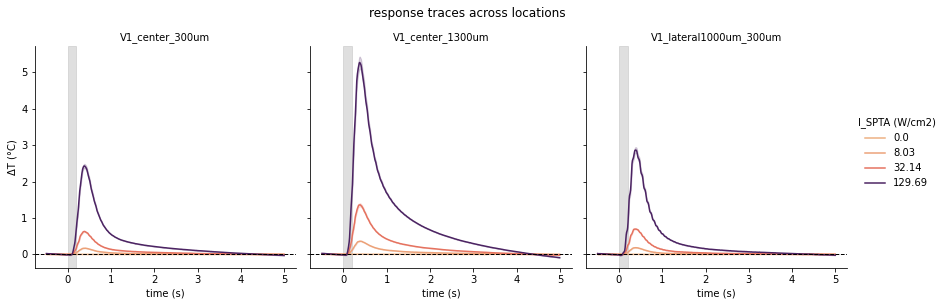

In [156]:
# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure
hue = Label.ISPTA
logger.info('plotting stimulus-evoked temperature traces across locations')
figkey = 'response traces across locations'
g = sns.FacetGrid(
    data=data.reset_index(),
    col='location',
    height=4,
)
g.set_titles(template='{col_name}')
g.map_dataframe(
    plot_evoked_thermal_response,
    y=REL_TEMP_KEY, 
    errorbar='se',
    hue=hue,
    palette='flare',
)
g.add_legend(title=hue)
figs[figkey] = g.figure
figs[figkey].suptitle(figkey, y=1.05)

### Aggregate traces across trials for each condition 

In [157]:
# Aggregate traces across trials for each condition 
aggdata = compute_trial_average(data)
aggdata

 2026/09/16 15:12:18: computing trial-average data by ['location', 'P (MPa)', 'I_SPPA (W/cm2)', 'I_SPTA (W/cm2)']


Fdrive (MHz)  \
location               P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)                  
V1_center_1300um       0.00    0.00           0.00           -0.491725         2.095   
                                                             -0.483375         2.095   
                                                             -0.475025         2.095   
                                                             -0.466675         2.095   
                                                             -0.458325         2.095   
...                                                                              ...   
V1_lateral1000um_300um 2.29    162.11         129.69          4.960825         2.095   
                                                              4.969175         2.095   
                                                              4.977525         2.095   
                                                              4.985875         2.095   
                                                              4.994225         2.095   

                                                                         Vpp (V)  \
location               P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)              
V1_center_1300um       0.00    0.00           0.00           -0.491725  0.000000   
                                                             -0.483375  0.000000   
                                                             -0.475025  0.000000   
                                                             -0.466675  0.000000   
                                                             -0.458325  0.000000   
...                                                                          ...   
V1_lateral1000um_300um 2.29    162.11         129.69          4.960825  0.612646   
                                                              4.969175  0.612646   
                                                              4.977525  0.612646   
                                                              4.985875  0.612646   
                                                              4.994225  0.612646   

                                                                        detrended T (°C)  \
location               P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)                      
V1_center_1300um       0.00    0.00           0.00           -0.491725         31.179863   
                                                             -0.483375         31.179548   
                                                             -0.475025         31.179474   
                                                             -0.466675         31.180108   
                                                             -0.458325         31.180908   
...                                                                                  ...   
V1_lateral1000um_300um 2.29    162.11         129.69          4.960825         30.430899   
                                                              4.969175         30.429477   
                                                              4.977525         30.428942   
                                                              4.985875         30.429102   
                                                              4.994225         30.429016   

                                                                        tstim (s)  \
location               P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)               
V1_center_1300um       0.00    0.00           0.00           -0.491725        0.2   
                                                             -0.483375        0.2   
                                                             -0.475025        0.2   
                                                             -0.466675        0.2   
                                                             -0.458325        0.2   
...                                       

### Fit double exponential to temperature data

 2026/09/16 15:12:18: fitting double exponential to trial-averaged temperature traces
 2026/09/16 15:12:18: constructing fitted double exponential traces
 2026/09/16 15:12:18: plotting t0 distribution
 2026/09/16 15:12:19: plotting peak distribution
 2026/09/16 15:12:19: plotting tau_rise distribution
 2026/09/16 15:12:19: plotting tau_decay distribution
 2026/09/16 15:12:19: plotting offset distribution


Text(0.5, 1.05, 'distribution of double exponential fit parameters')

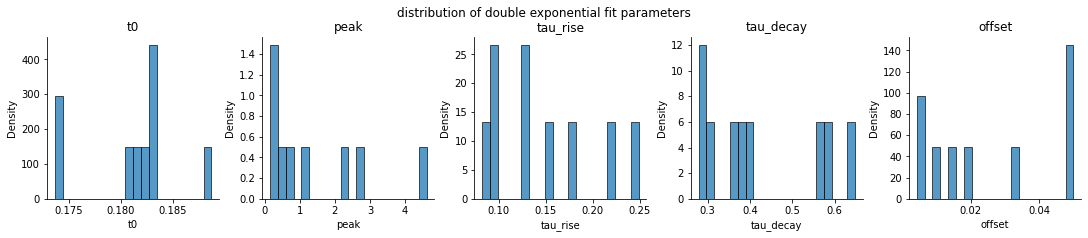

In [158]:
# Compute double exponential fits to the trial-averaged temperature traces
logger.info('fitting double exponential to trial-averaged temperature traces')
gby = [k for k in aggdata.index.names if k != TIME_KEY]
groups = aggdata.groupby(gby)[REL_TEMP_KEY]
fits = groups.apply(fit_double_exp).unstack('parameter')

# Construct fitted double exponential traces
logger.info('constructing fitted double exponential traces')
aggdata[f'fitted {REL_TEMP_KEY}'] = groups.apply(lambda x: pd.Series(
    double_exp_peak(
        x.index.get_level_values(TIME_KEY).values,
        *fits.loc[x.name].values),
    index=x.index.get_level_values(TIME_KEY))
)

naxes = len(fits.columns)
figkey = 'distribution of double exponential fit parameters'
figs[figkey], axes = plt.subplots(1, naxes, figsize=(3 * naxes, 3), constrained_layout=True)
for k, ax in zip(fits.columns, axes):
    logger.info(f'plotting {k} distribution')
    sns.histplot(
        fits[k],
        ax=ax,
        bins=20,
        stat='density',
    )
    ax.set_title(k)
    sns.despine(ax=ax)
figs[figkey].suptitle(figkey, y=1.05)

### Plot trial-averaged stim-evoked temperature traces and fitted double exponential traces

 2026/09/16 15:12:20: plotting stimulus-evoked temperature traces per location


Text(0.5, 1.05, 'trial-average response traces (with double-exponential fits) across locations')

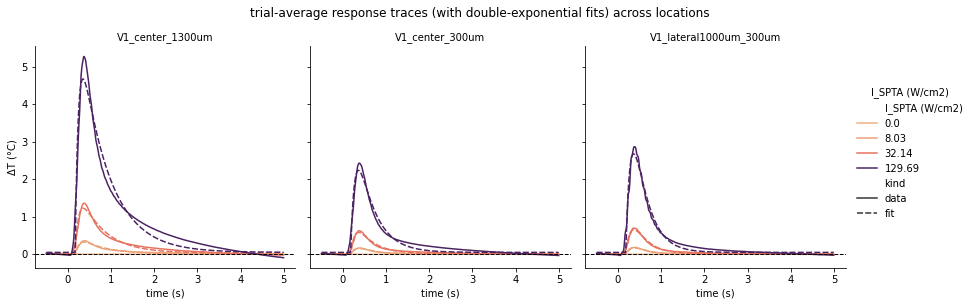

In [159]:
# Melt data by data/fit kind for plotting
ymap = {
    REL_TEMP_KEY: 'data',
    f'fitted {REL_TEMP_KEY}': 'fit'
}
melted_data = melt_by_condition(aggdata, ymap, 'kind')

# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure
hue = Label.ISPTA
logger.info(f'plotting stimulus-evoked temperature traces per location')
figkey = 'trial-average response traces (with double-exponential fits) across locations'
g = sns.FacetGrid(
    data=melted_data.reset_index(),
    col='location',
    height=4,
    sharex=False,
)
g.set_titles(template='{col_name}')
g.map_dataframe(
    plot_evoked_thermal_response,
    y=REL_TEMP_KEY,
    hue=hue,
    palette='flare',
    style='kind',
)
g.add_legend(title=hue)
figs[figkey] = g.figure
figs[figkey].suptitle(figkey, y=1.05)

### Compute max-evoked temperature change for each condition

In [160]:
# Compute max-evoked temperature change for each condition and trial
cond_keys = condition_keys(data)
logger.info('computing max-evoked temperature change for each condition and trial')
max_evoked_change = (
    data
    .groupby([*cond_keys, 'trial'])
    [REL_TEMP_KEY]
    .max()
    .rename(MAX_REL_TEMP_KEY)
)
max_evoked_change

logger.info('computing average max-evoked temperature change for each condition')
agg_max_evoked_change = (
    max_evoked_change
    .groupby(cond_keys)
    .mean()
)

 2026/09/16 15:12:21: computing max-evoked temperature change for each condition and trial
 2026/09/16 15:12:21: computing average max-evoked temperature change for each condition


### Plot dose-dependence of evoked temperature change at each location

 2026/09/16 15:12:21: plotting pressure dependence of temperature change at V1_center_300um
 2026/09/16 15:12:21: plotting ISPTA-dependent evoked temperature change traces
 2026/09/16 15:12:25: performing least-square linear fit on max_ΔT vs ISPTA
 2026/09/16 15:12:25: least-square linear fit: slope = 0.019 °C/(W/cm²), R² = 0.97
 2026/09/16 15:12:25: plotting ISPTA-dependence of max-evoked temperature change at focus
 2026/09/16 15:12:25: predicted max-evoked temperature change at 15.83 W/cm²: 0.300 °C
 2026/09/16 15:12:25: plotting pressure dependence of temperature change at V1_center_1300um
 2026/09/16 15:12:25: plotting ISPTA-dependent evoked temperature change traces
 2026/09/16 15:12:26: performing least-square linear fit on max_ΔT vs ISPTA
 2026/09/16 15:12:26: least-square linear fit: slope = 0.041 °C/(W/cm²), R² = 0.95
 2026/09/16 15:12:26: plotting ISPTA-dependence of max-evoked temperature change at focus
 2026/09/16 15:12:26: predicted max-evoked temperature change at 15.83

,ΔT (°C)
location,
V1_center_300um,0.299732
V1_center_1300um,0.649342
V1_lateral1000um_300um,0.351272


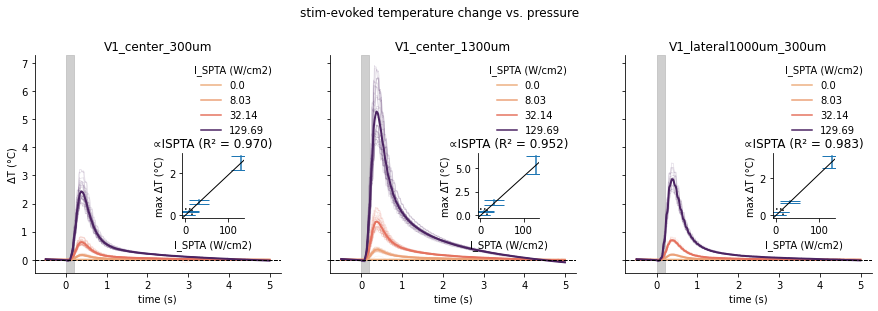

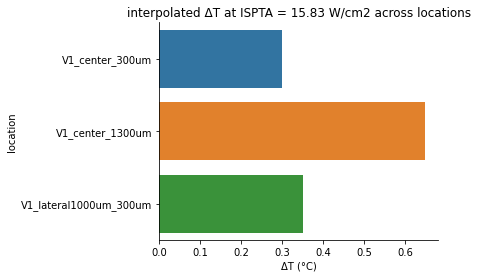

In [161]:
# Compute target ISPTA value corresponding to the reference pressure P_REF and experimental duty cycle DC
target_ISPPA = pressure_to_intensity(P_REF / PA_TO_MPA) / M2_TO_CM2  # W/cm2
target_ISPTA = np.round(target_ISPPA * DC / 1e2, 2)  # W/cm2

# Plot pressure dependence of temperature change at each location, with linear fit and R² value
locs = data.index.unique('location')
naxes = len(locs)
figkey = 'stim-evoked temperature change vs. pressure'
figs[figkey], axes = plt.subplots(1, naxes, figsize=(5 * naxes, 4), sharey=True)
figs[figkey].suptitle(figkey, y=1.05)
max_ΔT_pred_at_target_ISPTA = pd.Series(index=locs, dtype=float, name=REL_TEMP_KEY)
for loc, ax in zip(data.index.unique('location'), axes):
    logger.info(f'plotting pressure dependence of temperature change at {loc}')
    loc_data = data.loc[loc]
    loc_max_evoked_change = max_evoked_change.loc[loc]
    _, max_ΔT_pred_at_target_ISPTA.loc[loc] = plot_ispta_dependence(
        loc_data, loc_max_evoked_change, title=loc, ax=ax, Itarget=target_ISPTA)

# Plot bar graph of max ΔT predicted at target ISPTA across locations
figkey = f'interpolated ΔT at ISPTA = {target_ISPTA} W/cm2 across locations'
figs[figkey], ax = plt.subplots(figsize=(5, 4))
ax.set_title(figkey)
sns.despine(ax=ax)
sns.barplot(
    ax=ax,
    data=max_ΔT_pred_at_target_ISPTA.reset_index(),
    y='location',
    x=REL_TEMP_KEY,
)

logger.info(f'max ΔT predicted at ISPTA = {target_ISPTA} W/cm2:')
display(max_ΔT_pred_at_target_ISPTA.to_frame())

### Save figures

In [162]:
save_figs_book(figsdir, figs, suffix=experiment)

 2026/09/16 15:12:28: saving figures in /Users/tlemaire/Documents/data/US_thermal_experiments/figs/2026.09.16/figs_20260910_M01.pdf:


100%|██████████| 8/8 [00:01<00:00,  4.02it/s]
